In [18]:

#Importations
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, classification_report,  accuracy_score,f1_score,recall_score)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [7]:
!pip install tensorflow

In [2]:
df_imputed = pd.read_csv("../../data/weatherAUS_ForModel.csv")

X = df_imputed.drop(columns=["RainTomorrow", "Date", "SeasonName"], errors="ignore")
y = df_imputed["RainTomorrow"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Shape X: (140091, 22)
Shape y: (140091,)
Train size: (112072, 22)
Test size: (28019, 22)


In [3]:
scaler_nn = StandardScaler()

X_train_scaled = scaler_nn.fit_transform(X_train)
X_test_scaled = scaler_nn.transform(X_test)

In [4]:
model = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

c:\Users\acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [6]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8199 - loss: 0.4134 - val_accuracy: 0.8457 - val_loss: 0.3579
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8406 - loss: 0.3736 - val_accuracy: 0.8478 - val_loss: 0.3522
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8435 - loss: 0.3681 - val_accuracy: 0.8478 - val_loss: 0.3506
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8446 - loss: 0.3646 - val_accuracy: 0.8482 - val_loss: 0.3487
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8460 - loss: 0.3622 - val_accuracy: 0.8483 - val_loss: 0.3483
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8461 - loss: 0.3606 - val_accuracy: 0.8485 - val_loss: 0.3471
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8473 - loss: 0.3596 - val_accuracy: 0.8497 - val_loss: 0.3461
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8475 - loss: 0.3589 - val_accuracy: 0.

In [7]:
y_prob_nn = model.predict(X_test_scaled).ravel()
y_pred_nn = (y_prob_nn > 0.5).astype(int)

print("ROC-AUC Neural Network:", roc_auc_score(y_test, y_prob_nn))
print(classification_report(y_test, y_pred_nn))


results_nn = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_Class": y_pred_nn,
    "Predicted_Probability": y_prob_nn
})

results_nn.head(10)

876/876 ━━━━━━━━━━━━━━━━━━━━ 1s 905us/step
ROC-AUC Neural Network: 0.8772047790960481
              precision    recall  f1-score   support

           0       0.86      0.96      0.91     21757
           1       0.77      0.47      0.58      6262

    accuracy                           0.85     28019
   macro avg       0.81      0.71      0.75     28019
weighted avg       0.84      0.85      0.84     28019



,Actual,Predicted_Class,Predicted_Probability
0,0,0,0.151917
1,1,0,0.053619
2,0,0,0.223754
3,0,0,0.267784
4,0,0,0.071148
5,0,0,0.033161
6,0,0,0.036436
7,0,0,0.321456
8,0,0,0.142041
9,0,0,0.088044


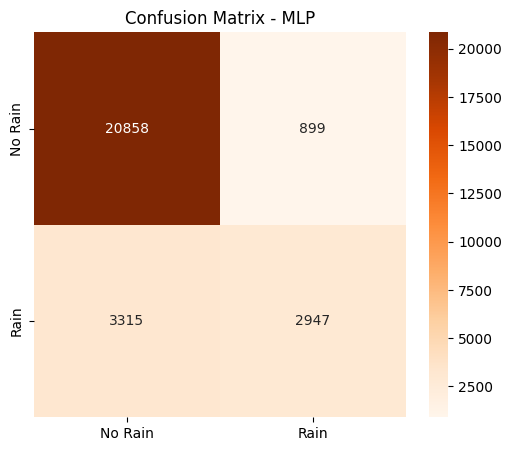

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_nn = confusion_matrix(y_test, y_pred_nn)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_nn,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"]
)

plt.title("Confusion Matrix - MLP")
plt.show()

Neural Network With SMOTE

In [9]:
print("Avant SMOTE :")
print(y_train.value_counts())
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("Après SMOTE :")
print(y_train_smote.value_counts())

Avant SMOTE :
RainTomorrow
0    87025
1    25047
Name: count, dtype: int64
Après SMOTE :
RainTomorrow
0    87025
1    87025
Name: count, dtype: int64


In [10]:
scaler_nn = StandardScaler()

X_train_smote_scaled = scaler_nn.fit_transform(X_train_smote)
X_test_scaled = scaler_nn.transform(X_test)

In [11]:
model_smote = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_train_smote_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

c:\Users\acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model_smote.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [13]:
history = model_smote.fit(
    X_train_smote_scaled,
    y_train_smote,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7717 - loss: 0.4806 - val_accuracy: 0.6515 - val_loss: 0.6370
Epoch 2/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7961 - loss: 0.4439 - val_accuracy: 0.6882 - val_loss: 0.6062
Epoch 3/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8006 - loss: 0.4362 - val_accuracy: 0.6822 - val_loss: 0.5968
Epoch 4/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8017 - loss: 0.4318 - val_accuracy: 0.6925 - val_loss: 0.5789
Epoch 5/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8045 - loss: 0.4263 - val_accuracy: 0.6919 - val_loss: 0.5839
Epoch 6/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8065 - loss: 0.4228 - val_accuracy: 0.7146 - val_loss: 0.5518
Epoch 7/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8084 - loss: 0.4203 - val_accuracy: 0.7155 - val_loss: 0.5444
Epoch 8/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8107 - loss: 0.4178 - val_accuracy: 0.

In [14]:
y_prob_nn_smote = model_smote.predict(X_test_scaled).ravel()
y_pred_nn_smote = (y_prob_nn_smote > 0.5).astype(int)

print("ROC-AUC  MLP + SMOTE:",
      roc_auc_score(y_test, y_prob_nn_smote))

print(classification_report(y_test, y_pred_nn_smote))


results_nn = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_Class": y_pred_nn_smote,
    "Predicted_Probability": y_prob_nn_smote
})

results_nn.head(10)

876/876 ━━━━━━━━━━━━━━━━━━━━ 1s 834us/step
ROC-AUC  MLP + SMOTE: 0.8766137990560261
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     21757
           1       0.67      0.61      0.64      6262

    accuracy                           0.85     28019
   macro avg       0.78      0.76      0.77     28019
weighted avg       0.84      0.85      0.84     28019



,Actual,Predicted_Class,Predicted_Probability
0,0,0,0.283166
1,1,0,0.089083
2,0,0,0.305195
3,0,1,0.588038
4,0,0,0.129503
5,0,0,0.024108
6,0,0,0.025232
7,0,0,0.419488
8,0,0,0.169776
9,0,0,0.140285


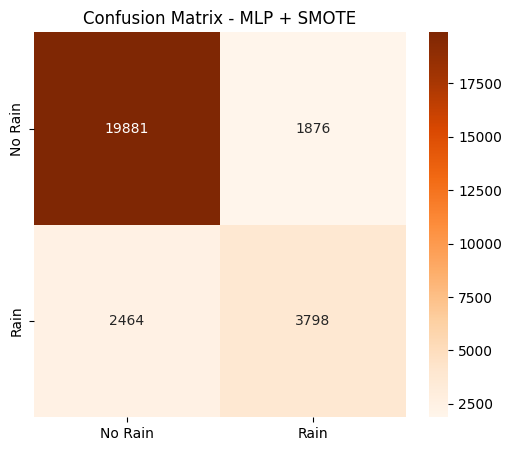

In [15]:
cm_nn_smote = confusion_matrix(y_test, y_pred_nn_smote)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_nn_smote,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"]
)

plt.title("Confusion Matrix - MLP + SMOTE")
plt.show()

Avec pondération des classes 


================ MLP (class_weight) ================

Ratio: 3.4744680001596997
Epoch 1/20


c:\Users\acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7484 - loss: 0.8099 - val_accuracy: 0.7889 - val_loss: 0.4593
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7821 - loss: 0.7427 - val_accuracy: 0.8003 - val_loss: 0.4388
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7850 - loss: 0.7301 - val_accuracy: 0.7951 - val_loss: 0.4513
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7848 - loss: 0.7251 - val_accuracy: 0.7898 - val_loss: 0.4514
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7856 - loss: 0.7197 - val_accuracy: 0.7930 - val_loss: 0.4477
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7867 - loss: 0.7170 - val_accuracy: 0.7968 - val_loss: 0.4388
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7879 - loss: 0.7140 - val_accuracy: 0.7965 - val_loss: 0.4374
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7891 - loss: 0.7127 - val_accuracy: 0.7935 - val_

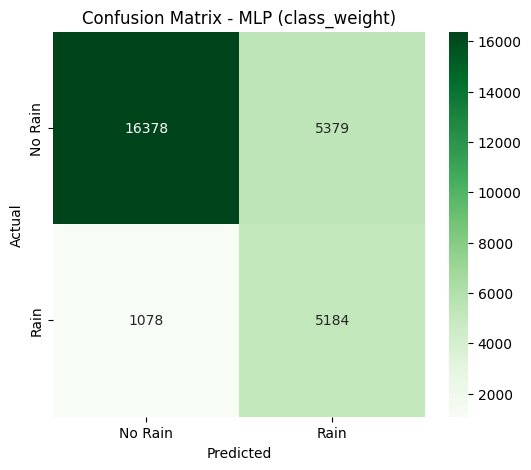

In [16]:
print("\n================ MLP (class_weight) ================\n")


neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
ratio = neg / pos

print("Ratio:", ratio)


class_weight = {
    0: 1,
    1: ratio
}


scaler_nn = StandardScaler()
X_train_scaled = scaler_nn.fit_transform(X_train)
X_test_scaled = scaler_nn.transform(X_test)


model_weight = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model_weight.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


history = model_weight.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    class_weight=class_weight,   
    verbose=1
)


y_prob_nn_weight = model_weight.predict(X_test_scaled).ravel()

threshold = 0.45
y_pred_nn_weight = (y_prob_nn_weight >= threshold).astype(int)


print("ROC-AUC MLP + class_weight:",
      roc_auc_score(y_test, y_prob_nn_weight))

print(classification_report(y_test, y_pred_nn_weight))


cm_nn_weight = confusion_matrix(y_test, y_pred_nn_weight)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_nn_weight,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"]
)

plt.title("Confusion Matrix - MLP (class_weight)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
print("\n================ TABLEAU COMPARATIF MLP ================\n")

threshold = 0.45
results_mlp = []


# MLP NORMAL

y_pred_nn = (y_prob_nn >= threshold).astype(int)

results_mlp.append({
    "Model": "MLP Normal",
    "Accuracy": accuracy_score(y_test, y_pred_nn),
    "F1": f1_score(y_test, y_pred_nn),
    "Recall": recall_score(y_test, y_pred_nn),
    "ROC-AUC": roc_auc_score(y_test, y_prob_nn)
})



# MLP + SMOTE

y_pred_nn_smote = (y_prob_nn_smote >= threshold).astype(int)

results_mlp.append({
    "Model": "MLP + SMOTE",
    "Accuracy": accuracy_score(y_test, y_pred_nn_smote),
    "F1": f1_score(y_test, y_pred_nn_smote),
    "Recall": recall_score(y_test, y_pred_nn_smote),
    "ROC-AUC": roc_auc_score(y_test, y_prob_nn_smote)
})



# MLP + class_weight

y_pred_nn_weight = (y_prob_nn_weight >= threshold).astype(int)

results_mlp.append({
    "Model": "MLP + class_weight",
    "Accuracy": accuracy_score(y_test, y_pred_nn_weight),
    "F1": f1_score(y_test, y_pred_nn_weight),
    "Recall": recall_score(y_test, y_pred_nn_weight),
    "ROC-AUC": roc_auc_score(y_test, y_prob_nn_weight)
})



df_mlp = pd.DataFrame(results_mlp)
print(df_mlp)


================ TABLEAU COMPARATIF MLP ================

                Model  Accuracy        F1    Recall   ROC-AUC
0          MLP Normal  0.851208  0.609315  0.519163  0.877205
1         MLP + SMOTE  0.837610  0.647177  0.666401  0.876614
2  MLP + class_weight  0.769549  0.616226  0.827851  0.877771
